In [1]:
# ============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px

# ============================================================================
# 2. CONFIGURACIÓN Y PARÁMETROS
# ============================================================================
# Configuración de visualización
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [5]:
# ============================================================================
# 3. LISTA DE TICKERS A ANALIZAR
# ============================================================================
tickers = [
    # Tecnología
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'IBM', 'ADBE', 'ORCL',
    # Consumo
    'MCD', 'KO', 'PEP', 'NKE', 'SBUX', 'PG', 'WMT', 'COST', 'TGT', 'DIS',
    # Energía
    'XOM', 'CVX', 'BP', 'SHEL', 'ENB', 'COP', 'SLB', 'EOG', 'PSX',
    # Salud
    'JNJ', 'PFE', 'MRK', 'UNH', 'ABBV', 'TMO', 'LLY', 'BMY', 'CVS', 'MDT',
    # Finanzas
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'AXP', 'C', 'SCHW', 'SPGI'
]

print(f"Número de empresas a analizar: {len(tickers)}")

Número de empresas a analizar: 49


In [9]:
# ============================================================================
# 4. DESCARGA DE DATOS
# ============================================================================
print("\n" + "="*60)
print("DESCARGANDO DATOS DE YAHOO FINANCE")
print("="*60)

try:
    data = yf.download(tickers, start='2025-01-01', end='2025-12-12')['Close']
    print(f"Datos descargados exitosamente")
    print(f"Período: 2025-01-01 al 2025-12-12")
    print(f"Forma de los datos: {data.shape}")
except Exception as e:
    print(f"Error descargando datos: {e}")
    raise

C:\Users\ramon\AppData\Local\Temp\ipykernel_15516\2006634537.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2025-01-01', end='2025-12-12')['Close']
[*****                 10%                       ]  5 of 49 completed


DESCARGANDO DATOS DE YAHOO FINANCE


[*********************100%***********************]  49 of 49 completed


Datos descargados exitosamente
Período: 2025-01-01 al 2025-12-12
Forma de los datos: (237, 49)


In [11]:
# ============================================================================
# 5. CÁLCULO DE RENTABILIDADES Y MÉTRICAS
# ============================================================================
print("\n" + "="*60)
print("CALCULANDO RENTABILIDADES Y MÉTRICAS")
print("="*60)

# Cálculo de rentabilidades diarias
returns = data.pct_change()
print(f"Rentabilidades calculadas")

# Métricas anualizadas
metrics = pd.DataFrame({
    'Rentabilidad_anual': returns.mean() * 252,
    'Volatilidad_anual': returns.std() * np.sqrt(252)
})
print(f"Métricas calculadas para {len(metrics)} empresas")


CALCULANDO RENTABILIDADES Y MÉTRICAS
Rentabilidades calculadas
Métricas calculadas para 49 empresas


In [17]:
# ============================================================================
# 6. NORMALIZACIÓN DE DATOS
# ============================================================================
print("\n" + "="*60)
print("NORMALIZANDO DATOS PARA CLUSTERING")
print("="*60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(metrics)

print(f"Datos normalizados")
print(f"Forma original: {metrics.shape}")
print(f"Forma normalizada: {X_scaled.shape}")


NORMALIZANDO DATOS PARA CLUSTERING
Datos normalizados
Forma original: (49, 2)
Forma normalizada: (49, 2)


In [19]:
# ============================================================================
# 7. APLICACIÓN DE K-MEANS CLUSTERING
# ============================================================================
print("\n" + "="*60)
print("APLICANDO ALGORITMO K-MEANS")
print("="*60)

# Configuración del modelo
n_clusters = 4
random_state = 100

print(f"⚙️  Parámetros del modelo:")
print(f"   • Número de clusters: {n_clusters}")
print(f"   • Random state: {random_state}")

# Creación y entrenamiento del modelo
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
metrics['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Clustering completado")
print(f"Distribución de empresas por cluster:")
print(metrics['Cluster'].value_counts().sort_index())


APLICANDO ALGORITMO K-MEANS
⚙️  Parámetros del modelo:
   • Número de clusters: 4
   • Random state: 100


C:\Users\ramon\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ramon\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ramon\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ramon\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ramon\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

Clustering completado
Distribución de empresas por cluster:
Cluster
0    15
1    17
2    14
3     3
Name: count, dtype: int64


C:\Users\ramon\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
# ============================================================================
# 8. CÁLCULO DEL SHARPE RATIO
# ============================================================================
print("\n" + "="*60)
print("CALCULANDO SHARPE RATIO")
print("="*60)

metrics['Sharpe'] = metrics['Rentabilidad_anual'] / metrics['Volatilidad_anual']
print(f"Sharpe Ratio calculado para cada empresa")


CALCULANDO SHARPE RATIO
Sharpe Ratio calculado para cada empresa


In [23]:
# ============================================================================
# 9. ANÁLISIS POR CLUSTER
# ============================================================================
print("\n" + "="*60)
print("ANÁLISIS DETALLADO POR CLUSTER")
print("="*60)

# Agrupación de resultados
resultados_clusters = metrics.groupby('Cluster').agg({
    'Rentabilidad_anual': 'mean',
    'Volatilidad_anual': 'mean',
    'Sharpe': 'mean'
}).sort_values(by='Sharpe', ascending=False)

print("\n RESUMEN POR CLUSTER (ordenados por Sharpe descendente):")
print("-" * 70)

for cluster, fila in resultados_clusters.iterrows():
    print(f"\n🔹 CLUSTER {cluster}:")
    print(f"   Rentabilidad media anual: {fila['Rentabilidad_anual']:.2%}")
    print(f"   Volatilidad media anual: {fila['Volatilidad_anual']:.2%}")
    print(f"   Sharpe Ratio medio: {fila['Sharpe']:.2f}")
    print(f"   Número de empresas: {sum(metrics['Cluster'] == cluster)}")


ANÁLISIS DETALLADO POR CLUSTER

 RESUMEN POR CLUSTER (ordenados por Sharpe descendente):
----------------------------------------------------------------------

🔹 CLUSTER 1:
   Rentabilidad media anual: 42.01%
   Volatilidad media anual: 29.91%
   Sharpe Ratio medio: 1.42
   Número de empresas: 17

🔹 CLUSTER 3:
   Rentabilidad media anual: 39.31%
   Volatilidad media anual: 59.05%
   Sharpe Ratio medio: 0.68
   Número de empresas: 3

🔹 CLUSTER 2:
   Rentabilidad media anual: 11.55%
   Volatilidad media anual: 22.48%
   Sharpe Ratio medio: 0.52
   Número de empresas: 14

🔹 CLUSTER 0:
   Rentabilidad media anual: 1.24%
   Volatilidad media anual: 34.71%
   Sharpe Ratio medio: 0.04
   Número de empresas: 15



GENERANDO VISUALIZACIONES
Gráfico generado exitosamente


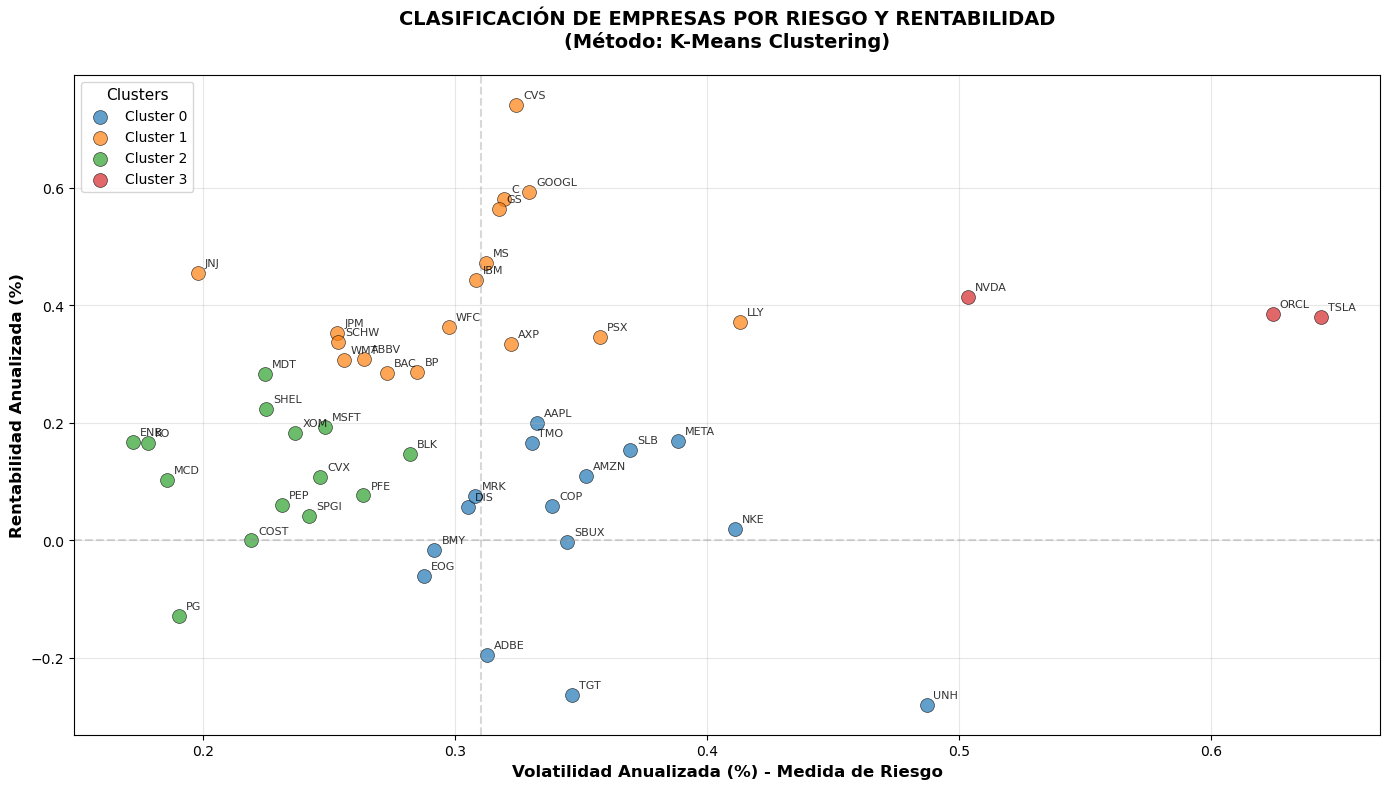

In [25]:
# ============================================================================
# 10. VISUALIZACIÓN DE RESULTADOS
# ============================================================================
print("\n" + "="*60)
print("GENERANDO VISUALIZACIONES")
print("="*60)

# Configuración de colores para los clusters
colores_clusters = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Creación del gráfico
fig, ax = plt.subplots(figsize=(14, 8))

# Graficar cada cluster
for cluster in metrics['Cluster'].unique():
    subset = metrics[metrics['Cluster'] == cluster]
    color_idx = cluster % len(colores_clusters)
    
    ax.scatter(
        subset['Volatilidad_anual'], 
        subset['Rentabilidad_anual'], 
        label=f'Cluster {cluster}',
        s=100,
        alpha=0.7,
        color=colores_clusters[color_idx],
        edgecolors='black',
        linewidth=0.5
    )
    
    # Etiquetas con tickers
    for ticker, row in subset.iterrows():
        ax.annotate(
            ticker,
            xy=(row['Volatilidad_anual'], row['Rentabilidad_anual']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8
        )

# Personalización del gráfico
ax.set_xlabel('Volatilidad Anualizada (%) - Medida de Riesgo', fontsize=12, fontweight='bold')
ax.set_ylabel('Rentabilidad Anualizada (%)', fontsize=12, fontweight='bold')
ax.set_title('CLASIFICACIÓN DE EMPRESAS POR RIESGO Y RENTABILIDAD\n(Método: K-Means Clustering)', 
             fontsize=14, fontweight='bold', pad=20)

# Líneas de referencia
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=metrics['Volatilidad_anual'].mean(), color='gray', linestyle='--', alpha=0.3)

# Cuadrícula y leyenda
ax.grid(True, alpha=0.3)
ax.legend(title='Clusters', title_fontsize=11, fontsize=10, loc='upper left')

# Ajustes finales
plt.tight_layout()
print("Gráfico generado exitosamente")
plt.show()

In [27]:
# ============================================================================
# 11. DETALLE COMPLETO POR CLUSTER
# ============================================================================
print("\n" + "="*60)
print("DETALLE COMPLETO POR EMPRESA Y CLUSTER")
print("="*60)

# Ordenar clusters por Sharpe
clusters_ordenados = resultados_clusters.index.tolist()

for cluster in clusters_ordenados:
    subset = metrics[metrics['Cluster'] == cluster]
    tickers_cluster = subset.index.tolist()
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster} - RESUMEN")
    print(f"{'='*70}")
    print(f"• Rentabilidad promedio: {subset['Rentabilidad_anual'].mean():.2%}")
    print(f"• Volatilidad promedio: {subset['Volatilidad_anual'].mean():.2%}")
    print(f"• Sharpe promedio: {subset['Sharpe'].mean():.2f}")
    print(f"• Número de empresas: {len(subset)}")
    print(f"\n📈 EMPRESAS EN ESTE CLUSTER ({len(subset)}):")
    print("-" * 40)
    
    # Ordenar empresas por Sharpe
    empresas_ordenadas = subset.sort_values('Sharpe', ascending=False)
    
    for ticker, row in empresas_ordenadas.iterrows():
        print(f"  {ticker:5s} | Rent: {row['Rentabilidad_anual']:7.2%} | Vol: {row['Volatilidad_anual']:6.2%} | Sharpe: {row['Sharpe']:6.2f}")


DETALLE COMPLETO POR EMPRESA Y CLUSTER

CLUSTER 1 - RESUMEN
• Rentabilidad promedio: 42.01%
• Volatilidad promedio: 29.91%
• Sharpe promedio: 1.42
• Número de empresas: 17

📈 EMPRESAS EN ESTE CLUSTER (17):
----------------------------------------
  JNJ   | Rent:  45.49% | Vol: 19.80% | Sharpe:   2.30
  CVS   | Rent:  74.11% | Vol: 32.44% | Sharpe:   2.28
  C     | Rent:  58.15% | Vol: 31.95% | Sharpe:   1.82
  GOOGL | Rent:  59.28% | Vol: 32.95% | Sharpe:   1.80
  GS    | Rent:  56.38% | Vol: 31.77% | Sharpe:   1.77
  MS    | Rent:  47.15% | Vol: 31.22% | Sharpe:   1.51
  IBM   | Rent:  44.33% | Vol: 30.84% | Sharpe:   1.44
  JPM   | Rent:  35.32% | Vol: 25.34% | Sharpe:   1.39
  SCHW  | Rent:  33.72% | Vol: 25.38% | Sharpe:   1.33
  WFC   | Rent:  36.33% | Vol: 29.76% | Sharpe:   1.22
  WMT   | Rent:  30.71% | Vol: 25.61% | Sharpe:   1.20
  ABBV  | Rent:  30.84% | Vol: 26.38% | Sharpe:   1.17
  BAC   | Rent:  28.50% | Vol: 27.30% | Sharpe:   1.04
  AXP   | Rent:  33.47% | Vol: 32.24%

In [29]:
# ============================================================================
# 12. RESUMEN DEL ANÁLISIS
# ============================================================================
print("\n" + "="*60)
print("RESUMEN DEL ANÁLISIS")
print("="*60)

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Total empresas analizadas: {len(metrics)}")
print(f"   • Rentabilidad promedio: {metrics['Rentabilidad_anual'].mean():.2%}")
print(f"   • Volatilidad promedio: {metrics['Volatilidad_anual'].mean():.2%}")
print(f"   • Sharpe promedio: {metrics['Sharpe'].mean():.2f}")

print(f"\n MEJORES CLUSTERS POR SHARPE RATIO:")
print("-" * 50)

for i, (cluster, fila) in enumerate(resultados_clusters.iterrows()):
    if i < 3:  # Mostrar top 3
        emoji = "🥇" if i == 0 else "🥈" if i == 1 else "🥉"
        print(f"{emoji} Cluster {cluster}: Sharpe = {fila['Sharpe']:.2f} "
              f"(Rent: {fila['Rentabilidad_anual']:.2%}, Vol: {fila['Volatilidad_anual']:.2%})")

print(f"\n DISTRIBUCIÓN DE EMPRESAS POR CLUSTER:")
print("-" * 50)
distribucion = metrics['Cluster'].value_counts().sort_index()
for cluster, count in distribucion.items():
    porcentaje = (count / len(metrics)) * 100
    print(f"   Cluster {cluster}: {count:2d} empresas ({porcentaje:.1f}%)")

print("\n" + "="*60)
print("ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*60)

# ============================================================================
# 13. DATOS PARA EXPORTACIÓN (OPCIONAL)
# ============================================================================
print("\n💾 DATOS DISPONIBLES PARA EXPORTACIÓN:")
print(f"   • 'metrics': DataFrame con todas las métricas por empresa")
print(f"   • 'resultados_clusters': Resumen agregado por cluster")
print(f"   • 'returns': Rentabilidades diarias de todas las empresas")


RESUMEN DEL ANÁLISIS

 ESTADÍSTICAS GLOBALES:
   • Total empresas analizadas: 49
   • Rentabilidad promedio: 20.66%
   • Volatilidad promedio: 31.04%
   • Sharpe promedio: 0.70

 MEJORES CLUSTERS POR SHARPE RATIO:
--------------------------------------------------
🥇 Cluster 1: Sharpe = 1.42 (Rent: 42.01%, Vol: 29.91%)
🥈 Cluster 3: Sharpe = 0.68 (Rent: 39.31%, Vol: 59.05%)
🥉 Cluster 2: Sharpe = 0.52 (Rent: 11.55%, Vol: 22.48%)

 DISTRIBUCIÓN DE EMPRESAS POR CLUSTER:
--------------------------------------------------
   Cluster 0: 15 empresas (30.6%)
   Cluster 1: 17 empresas (34.7%)
   Cluster 2: 14 empresas (28.6%)
   Cluster 3:  3 empresas (6.1%)

ANÁLISIS COMPLETADO EXITOSAMENTE

💾 DATOS DISPONIBLES PARA EXPORTACIÓN:
   • 'metrics': DataFrame con todas las métricas por empresa
   • 'resultados_clusters': Resumen agregado por cluster
   • 'returns': Rentabilidades diarias de todas las empresas
